<a href="https://colab.research.google.com/github/VincenzoDamico/ProteinDynamics/blob/LSTM/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



# Library setting



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from sklearn.preprocessing import StandardScaler
import os
import random

Seeting the seeds:

In [3]:
# fix random seed for reproducibility
def set_all_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_all_seeds(42)
np.random.seed(42) #it also fix the seed for sklearn

# Inizialization of Input Data

In [4]:
driver_path='/content/drive/MyDrive/ProteinDynamics/'

In [6]:
coordinates_df = pd.read_csv(driver_path+'coordinates.csv', header=None, index_col=False, sep=';')
# header= none: we don't have col names in the first raw
# index_col: we don't have a col for the index
print(coordinates_df.head(), coordinates_df.shape)

# Forces:
forces_df_raw = pd.read_csv(driver_path+'forces.csv', header=None, index_col=False, sep=None, engine='python')
# sep = none means pandas will search to find the separator
forces_df = forces_df_raw[0].str.split('\t', expand=True)
forces_df = forces_df.apply(pd.to_numeric, errors='coerce')
print(forces_df.head(), forces_df.shape)

# velocity:
velocities_df_raw = pd.read_csv(driver_path+'velocity.csv', header=None, index_col=False, sep=None, engine='python')
velocities_df = velocities_df_raw[0].str.split('\t', expand=True)
velocities_df = velocities_df.apply(pd.to_numeric, errors='coerce')
print(velocities_df.head(), velocities_df.shape)

     0        1        2        3        4        5        6        7    \
0  0.000  56.3980  51.9370  52.6880  56.3750  52.0050  52.6170  56.4260   
1  0.002  56.3992  51.9368  52.6877  56.3743  52.0037  52.6162  56.4267   
2  0.004  56.3999  51.9366  52.6871  56.3767  52.0046  52.6161  56.4285   
3  0.006  56.4001  51.9364  52.6861  56.3816  52.0073  52.6167  56.4315   
4  0.008  56.4001  51.9362  52.6848  56.3876  52.0109  52.6179  56.4350   

       8        9    ...      405      406      407      408      409  \
0  51.8530  52.6400  ...  52.1880  56.7460  52.0040  52.3850  56.7650   
1  51.8556  52.6344  ...  52.1872  56.7448  52.0025  52.3849  56.7651   
2  51.8579  52.6307  ...  52.1890  56.7434  52.0011  52.3842  56.7652   
3  51.8594  52.6288  ...  52.1930  56.7417  52.0001  52.3832  56.7652   
4  51.8597  52.6288  ...  52.1982  56.7402  51.9995  52.3824  56.7651   

       410      411      412      413      414  
0  51.9040  52.4540  56.7550  52.1200  52.4210  
1  51.9044  


LSTMs are sensitive to the scale of the input data, specifically when the sigmoid (default) or tanh activation functions are used. It can be a good practice to rescale the data to the range of 0-to-1



In [7]:
coords = coordinates_df.iloc[:, 1:].values
vels   = velocities_df.iloc[:, 1:].values
forces = forces_df.iloc[:, 1:].values
timestamp=coordinates_df.iloc[:,0].values


#RESHAPE TO (timesteps, atoms, xyz)
NUM_ATOMS = 138
Coordinate=3

coords = coords.reshape(-1,NUM_ATOMS, 3)
vels   = vels.reshape(-1, NUM_ATOMS, 3)
forces = forces.reshape(-1, NUM_ATOMS, 3)

print("\nAfter reshape:")
print("Coordinates:", coords.shape)
print("Velocities :", vels.shape)
print("Forces     :", forces.shape)

#3- Concatenate Features to be [x,y,z,vx,vy,vz,fx,fy,fz]
features = np.concatenate(
    [coords, vels, forces],
    axis=-1
)

print("\nCombined features shape:")
print(features.shape)
N         = len(features)       # 50001
train_end = int(N * 0.70)       # 35000
val_end   = int(N * 0.85)       # 42500

# Fit scaler on training data ONLY — prevents leakage from future frames
train_data = coords[:train_end].reshape(-1, 3)   # (35000*138, 9)

scaler = StandardScaler()
scaler.fit(train_data)

def scale_data(data):
    T = data.shape[0]
    data_scaled = scaler.transform(data.reshape(-1, 3))
    return data_scaled.reshape(T, 138, 3).astype('float32')

# features shape = (50001,138,9)

features_scaled = scale_data(coords)
features_scaled.shape




After reshape:
Coordinates: (50001, 138, 3)
Velocities : (50001, 138, 3)
Forces     : (50001, 138, 3)

Combined features shape:
(50001, 138, 9)


(50001, 138, 3)

Adjust the input data to match the LMTS Model standard. The LSTM network expects the input data (X) to be provided with a specific array structure in the form of [samples, time steps, features].


# Coordinate prediction

In this case i will build my feature vector as
my previous 3 positions and the previous force and velocity.

In [8]:
look_back=3

In [9]:
nb_samples = features_scaled.shape[0] - look_back
num_features=features_scaled.shape[2]*features_scaled.shape[1]

x_reshaped = np.zeros((nb_samples, look_back, num_features))
y_reshaped = np.zeros((nb_samples,num_features))

for i in range(nb_samples):
    y_position = i + look_back
    x_reshaped[i] = features_scaled[i:y_position].reshape(look_back,num_features)
    y_reshaped[i] = features_scaled[y_position].reshape(1,num_features)

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_features)
])
trainX=x_reshaped[:train_end]
testX=x_reshaped[train_end:val_end]
valX=x_reshaped[val_end:]
trainY=y_reshaped[:train_end]
testY=y_reshaped[train_end:val_end]
valY=y_reshaped[val_end:]
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4), # default 0.01
              metrics=['accuracy'])

history = model.fit(x=trainX,y=trainY, epochs=10,
                    validation_data=(valX,valY),
                    validation_steps=30)# make predictions
trainPredict = model.predict(trainX)
# make predictions


Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.0031 - loss: -16.7812 - val_accuracy: 0.0000e+00 - val_loss: -516.1602
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.0424 - loss: -112.1478 - val_accuracy: 0.0000e+00 - val_loss: -1874.6600
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.0822 - loss: -280.1920 - val_accuracy: 0.0000e+00 - val_loss: -3763.2161
Epoch 4/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.1412 - loss: -505.8750 - val_accuracy: 0.0000e+00 - val_loss: -6155.1353
Epoch 5/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.1441 - loss: -782.4968 - val_accuracy: 0.0000e+00 - val_loss: -8973.9834
Epoch 6/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.1443 - loss: -1109.4858 - val_accuracy: 0.0000e+00 - val_loss: -12243.3535
Epoch 7/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.1445 - loss: -1486.5669 - val_accuracy: 0.0000e+00 - val_loss: -15965.9229
Epoch 8/

In [17]:
test_loss, test_acc = model.evaluate(testX,testY)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0000e+00 - loss: -21087.0898
Test Loss: -21087.08984375
Test Accuracy: 0.0


(0.0, 1474.0602423667908)

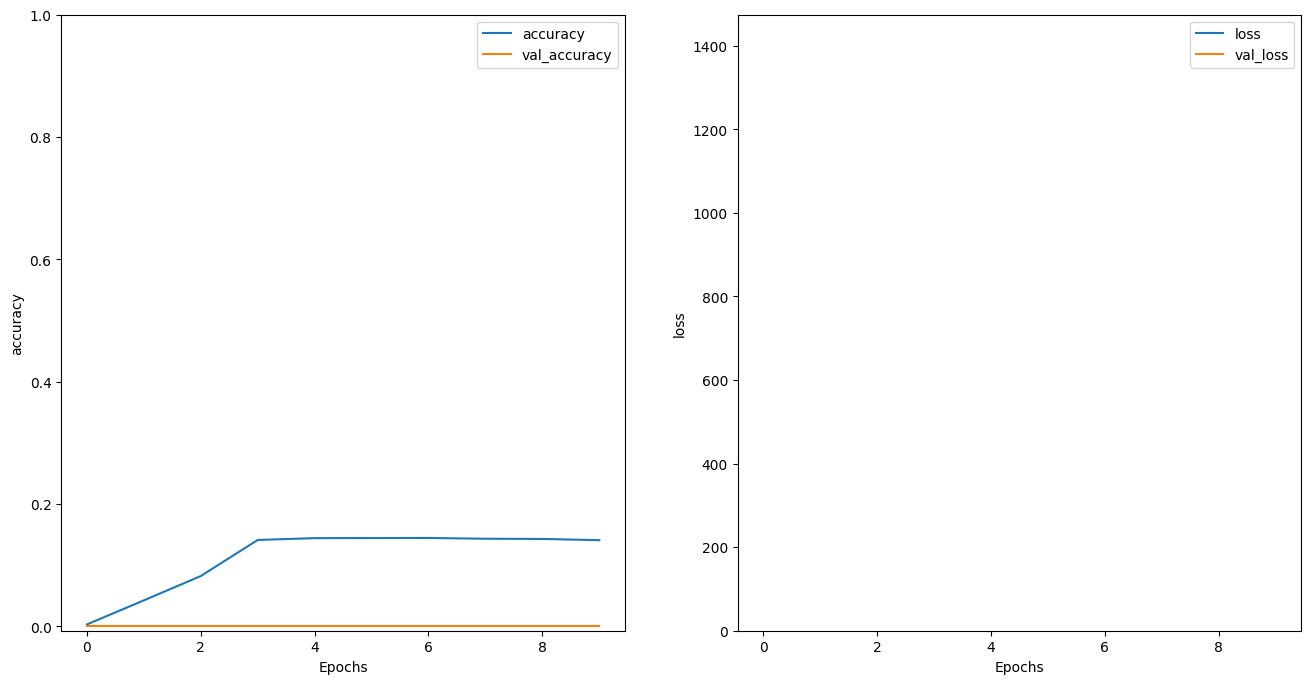

In [18]:

def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])


plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)